In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
!pip install -q albumentations timm
!git clone --depth 1 https://github.com/VainF/DeepLabV3Plus-Pytorch.git /kaggle/working/DeepLabV3Plus-Pytorch
import sys
sys.path.insert(0, '/kaggle/working/DeepLabV3Plus-Pytorch')
print('✓ Done')

Cloning into '/kaggle/working/DeepLabV3Plus-Pytorch'...
remote: Enumerating objects: 54, done.
remote: Counting objects: 100% (54/54), done.
remote: Compressing objects: 100% (53/53), done.
remote: Total 54 (delta 0), reused 31 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (54/54), 2.11 MiB | 28.42 MiB/s, done.
✓ Done


In [2]:
import os, cv2, time, random, json, warnings, hashlib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from torch.amp import GradScaler, autocast
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix)
warnings.filterwarnings('ignore')

# ── Config ─────────────────────────────────────────────────
SEED         = 42
IMG_SIZE     = 384
BATCH_SIZE   = 8
NUM_WORKERS  = 4
EPOCHS       = 20
LR           = 3e-4
WEIGHT_DECAY = 1e-4
POS_WEIGHT   = 3.0
BCE_WEIGHT   = 0.5
PATIENCE     = 5
THRESHOLD    = 0.5
DATA_ROOT    = '/kaggle/input/datasets/araftahsanpavel/tgif-subset/subset'
OUT_DIR      = '/kaggle/working'
DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MEAN     = [0.485, 0.456, 0.406]
STD      = [0.229, 0.224, 0.225]
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
print('✓ torch  :', torch.__version__)
print('✓ device :', DEVICE)
if torch.cuda.is_available():
    print('✓ GPU    :', torch.cuda.get_device_name(0))
    print('✓ VRAM   :', round(
        torch.cuda.get_device_properties(0).total_memory/1e9, 2), 'GB')
print('✓ Config set')

✓ torch  : 2.10.0+cu128
✓ device : cuda
✓ GPU    : Tesla T4
✓ VRAM   : 15.64 GB
✓ Config set


In [3]:
for split in ['training', 'validation', 'testing']:
    def count_files(d):
        total = 0
        if os.path.isdir(d):
            for r, _, files in os.walk(d):
                total += len(files)
        return total
    print(f'  {split:10s} ->'
          f' fakes:{count_files(os.path.join(DATA_ROOT,split,"fakes")):5d}'
          f' masks:{count_files(os.path.join(DATA_ROOT,split,"masks")):5d}'
          f' images:{count_files(os.path.join(DATA_ROOT,split,"images")):5d}')
print('✓ Dataset verified')

  training   -> fakes: 5459 masks: 4200 images: 2100
  validation -> fakes:  682 masks:  682 images:  341
  testing    -> fakes:  686 masks:  686 images:  343
✓ Dataset verified


In [4]:
def get_transforms(split, augment=False):
    norm = [A.Normalize(mean=MEAN, std=STD), ToTensorV2()]
    if split == 'training' and augment:
        return A.Compose([
            A.Resize(IMG_SIZE, IMG_SIZE),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.3),
            A.RandomRotate90(p=0.3),
            A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1,
                               rotate_limit=15, p=0.4),
            A.ElasticTransform(alpha=80, sigma=10, p=0.2),
            A.GridDistortion(num_steps=5, distort_limit=0.2, p=0.2),
            A.RandomBrightnessContrast(brightness_limit=0.3,
                                       contrast_limit=0.3, p=0.5),
            A.HueSaturationValue(hue_shift_limit=10,
                                 sat_shift_limit=20,
                                 val_shift_limit=10, p=0.3),
            A.CLAHE(clip_limit=2.0, p=0.3),
            A.RandomGamma(gamma_limit=(80, 120), p=0.3),
            A.GaussNoise(var_limit=(10, 50), p=0.3),
            A.GaussianBlur(blur_limit=(3, 5), p=0.2),
            A.MotionBlur(blur_limit=5, p=0.2),
            A.ImageCompression(quality_lower=75, quality_upper=100, p=0.3),
            A.CoarseDropout(max_holes=8, max_height=32,
                            max_width=32, p=0.2),
            *norm,
        ])
    else:
        return A.Compose([A.Resize(IMG_SIZE, IMG_SIZE), *norm])

print('✓ Transforms ready')

✓ Transforms ready


In [5]:
class TGIFDataset(Dataset):
    def __init__(self, root, split='training',
                 augment=False, include_authentic=True):
        self.transform = get_transforms(split, augment)
        self.samples   = []
        split_dir  = os.path.join(root, split)
        fakes_dir  = os.path.join(split_dir, 'fakes')
        masks_dir  = os.path.join(split_dir, 'masks')
        images_dir = os.path.join(split_dir, 'images')
        categories = []
        if os.path.isdir(fakes_dir):
            categories = [d for d in os.listdir(fakes_dir)
                          if os.path.isdir(os.path.join(fakes_dir, d))]
        for cat in sorted(categories):
            cat_fakes  = os.path.join(fakes_dir,  cat)
            cat_masks  = os.path.join(masks_dir,  cat)
            cat_images = os.path.join(images_dir, cat)
            mask_files = {}
            if os.path.isdir(cat_masks):
                for f in os.listdir(cat_masks):
                    if os.path.splitext(f)[1].lower() in IMG_EXTS:
                        mask_files[f] = os.path.join(cat_masks, f)
            if os.path.isdir(cat_fakes):
                for fake_name in sorted(os.listdir(cat_fakes)):
                    if os.path.splitext(fake_name)[1].lower() not in IMG_EXTS:
                        continue
                    matched = None
                    fake_stem = os.path.splitext(fake_name)[0]
                    for mname, mpath in mask_files.items():
                        mask_stem = os.path.splitext(mname)[0]
                        if fake_stem == mask_stem or fake_name.startswith(mask_stem):
                            matched = mpath
                            break
                    if matched:
                        self.samples.append((
                            os.path.join(cat_fakes, fake_name),
                            matched, 1))
            if include_authentic and os.path.isdir(cat_images):
                for f in sorted(os.listdir(cat_images)):
                    if os.path.splitext(f)[1].lower() in IMG_EXTS:
                        self.samples.append((
                            os.path.join(cat_images, f),
                            None, 0))
        tag      = f"{'aug-' if augment else ''}{split}"
        n_forged = sum(1 for s in self.samples if s[2] == 1)
        n_auth   = sum(1 for s in self.samples if s[2] == 0)
        print(f'[{tag}] total:{len(self.samples):5d}  '
              f'forged:{n_forged:5d}  authentic:{n_auth:5d}')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, mask_path, label = self.samples[idx]
        img = cv2.imread(img_path)
        if img is None:
            img = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
        else:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        if mask_path is not None:
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            if mask is None:
                mask = np.zeros(img.shape[:2], dtype=np.uint8)
            else:
                if mask.shape != img.shape[:2]:
                    mask = cv2.resize(
                        mask, (img.shape[1], img.shape[0]),
                        interpolation=cv2.INTER_NEAREST)
                mask = (mask > 127).astype(np.uint8)
        else:
            mask = np.zeros(img.shape[:2], dtype=np.uint8)
        out         = self.transform(image=img, mask=mask)
        image       = out['image'].float()
        mask_tensor = out['mask'].unsqueeze(0).float()
        label_t     = torch.tensor(float(label))
        return image, mask_tensor, label_t

print('✓ TGIFDataset defined')

✓ TGIFDataset defined


In [6]:
print('Building datasets...')
train_ds = TGIFDataset(DATA_ROOT, 'training',   augment=True)
val_ds   = TGIFDataset(DATA_ROOT, 'validation',  augment=False)
test_ds  = TGIFDataset(DATA_ROOT, 'testing',     augment=False)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True,
    drop_last=True, persistent_workers=True)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
    persistent_workers=True)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
    persistent_workers=True)

imgs, masks, labels = next(iter(train_loader))
print(f'\n✓ Image batch  : {imgs.shape}')
print(f'✓ Mask  batch  : {masks.shape}')
print(f'✓ Label batch  : {labels.shape}')
print(f'✓ Foreground   : {masks.mean().item()*100:.2f}%')

Building datasets...
[aug-training] total: 7559  forged: 5459  authentic: 2100
[validation] total: 1023  forged:  682  authentic:  341
[testing] total: 1029  forged:  686  authentic:  343

✓ Image batch  : torch.Size([8, 3, 384, 384])
✓ Mask  batch  : torch.Size([8, 1, 384, 384])
✓ Label batch  : torch.Size([8])
✓ Foreground   : 0.95%


In [7]:
class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=BCE_WEIGHT, pos_weight=POS_WEIGHT):
        super().__init__()
        self.bce_w = bce_weight
        pw = torch.tensor([pos_weight]).to(DEVICE)
        self.bce = nn.BCEWithLogitsLoss(pos_weight=pw)

    def dice_loss(self, logits, targets, smooth=1.):
        probs = torch.sigmoid(logits)
        num   = (probs * targets).sum(dim=(1, 2, 3))
        den   = probs.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3)) + smooth
        return 1 - (2 * num + smooth) / den

    def forward(self, logits, targets):
        bce  = self.bce(logits, targets)
        dice = self.dice_loss(logits, targets).mean()
        return self.bce_w * bce + (1 - self.bce_w) * dice


def compute_batch_metrics(logits, masks, threshold=THRESHOLD):
    preds = (torch.sigmoid(logits) > threshold).float()
    tp = (preds * masks).sum().item()
    fp = (preds * (1 - masks)).sum().item()
    fn = ((1 - preds) * masks).sum().item()
    tn = ((1 - preds) * (1 - masks)).sum().item()
    iou  = tp / (tp + fp + fn + 1e-8)
    dice = 2 * tp / (2 * tp + fp + fn + 1e-8)
    acc  = (tp + tn) / (tp + tn + fp + fn + 1e-8)
    return iou, dice, acc


criterion = BCEDiceLoss()
print('✓ Loss & metrics ready')

✓ Loss & metrics ready


In [8]:
# ─────────────────────────────────────────────────────────────────────
# DeepLabV3+ (Chen et al., ECCV 2018)
#   via VainF/DeepLabV3Plus-Pytorch
#
# Key idea over DeepLabV3:
#   Adds a lightweight decoder that fuses low-level encoder features
#   (stride-4) with the ASPP output (stride-16/8), recovering fine
#   spatial detail cheaply.
#
# Architecture used here:
#   Backbone  : ResNet-50 (ImageNet pretrained via torchvision)
#   ASPP      : atrous rates [6,12,18], output_stride=16
#   Decoder   : 3×3 conv fusing stride-4 skip + upsampled ASPP output
#   Head      : 1×1 conv → 1 channel (binary segmentation logit)
# ─────────────────────────────────────────────────────────────────────

import network   # imported from the cloned VainF repo on sys.path

def build_model():
    # num_classes=1  → single binary logit map (matches BCEDiceLoss)
    # output_stride=16 → good balance of speed vs. detail on 384px input
    model = network.modeling.__dict__['deeplabv3plus_resnet50'](
        num_classes=1,
        output_stride=16,
        pretrained_backbone=True,
    )

    # Replace the pretrained classifier head weights — they are
    # incompatible with num_classes=1 (VOC head was 21 classes).
    # torchvision's ResNet backbone weights are kept frozen initially.
    nn.init.kaiming_normal_(
        model.classifier.classifier[-1].weight,
        mode='fan_out', nonlinearity='relu')
    nn.init.zeros_(model.classifier.classifier[-1].bias)

    return model.to(DEVICE)


# ── Sanity check ─────────────────────────────────────────────
_m = build_model()
_x = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
with torch.no_grad():
    _out = _m(_x)
total_p = sum(p.numel() for p in _m.parameters())
print(f'✓ DeepLabV3+ output shape : {_out.shape}')
print(f'✓ Total params            : {total_p/1e6:.2f} M')
del _m, _x, _out
torch.cuda.empty_cache()

Downloading: "https://download.pytorch.org/models/resnet50-19c8e357.pth" to /root/.cache/torch/hub/checkpoints/resnet50-19c8e357.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 573MB/s]


✓ DeepLabV3+ output shape : torch.Size([2, 1, 384, 384])
✓ Total params            : 39.76 M


In [9]:
def train_model(model, train_loader, val_loader,
                epochs=EPOCHS, lr=LR, run_name='deeplabv3p'):
    """
    Training strategy:
      • Epochs 0-2  : backbone frozen, ASPP + decoder only
      • Epoch  3+   : full network, backbone at lr/10
      • Scheduler   : CosineAnnealingWarmRestarts
      • AMP fp16    : halves VRAM
      • Grad accum  : 2 steps (effective batch = 16)
      • Grad clip   : max norm 1.0
      • Early stop  : PATIENCE epochs on val IoU
      • Best model  : saved on each val IoU improvement
    """
    scaler      = GradScaler('cuda')
    ACCUM_STEPS = 2

    # DeepLabV3+ splits into backbone vs. head (ASPP + decoder)
    backbone_params = list(model.backbone.parameters())
    backbone_ids    = {id(p) for p in backbone_params}

    def set_backbone_grad(req_grad):
        for p in backbone_params:
            p.requires_grad = req_grad

    # Phase 1: backbone frozen
    set_backbone_grad(False)
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=5, T_mult=2, eta_min=1e-6)

    history = {k: [] for k in [
        'train_loss', 'val_loss', 'train_acc', 'val_acc',
        'train_iou',  'val_iou',  'train_dice', 'val_dice',
        'epoch_time']}

    best_val_iou   = 0.0
    patience_count = 0
    save_path      = os.path.join(OUT_DIR, f'best_{run_name}.pth')
    total_start    = time.time()

    for epoch in range(epochs):
        ep_start = time.time()

        # Phase 2: unfreeze backbone at epoch 3
        if epoch == 3:
            set_backbone_grad(True)
            head_params = [p for p in model.parameters()
                           if id(p) not in backbone_ids]
            optimizer = torch.optim.AdamW([
                {'params': backbone_params, 'lr': lr * 0.1},
                {'params': head_params,     'lr': lr},
            ], weight_decay=WEIGHT_DECAY)
            scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
                optimizer, T_0=4, T_mult=2, eta_min=1e-7)
            print(f'  ✓ Backbone unfrozen — epoch {epoch+1}')

        # ── Train ───────────────────────────────────────────
        model.train()
        tl = ti = td = ta = 0.0
        optimizer.zero_grad(set_to_none=True)

        for step, (imgs, masks, _) in enumerate(tqdm(
                train_loader,
                desc=f'[{run_name}] Ep{epoch+1}/{epochs} Train',
                leave=False)):

            imgs  = imgs.to(DEVICE, non_blocking=True)
            masks = masks.to(DEVICE, non_blocking=True)

            with autocast('cuda'):
                logits = model(imgs)          # (B,1,H,W)
                loss   = criterion(logits, masks) / ACCUM_STEPS

            scaler.scale(loss).backward()

            if (step+1) % ACCUM_STEPS == 0 or (step+1) == len(train_loader):
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad(set_to_none=True)

            scheduler.step(epoch + step / len(train_loader))
            iou, dice, acc = compute_batch_metrics(
                logits.detach().float(), masks)
            tl += loss.item() * ACCUM_STEPS
            ti += iou; td += dice; ta += acc

        n = len(train_loader)
        history['train_loss'].append(tl / n)
        history['train_iou'].append(ti / n)
        history['train_dice'].append(td / n)
        history['train_acc'].append(ta / n)

        # ── Validate ────────────────────────────────────────
        model.eval()
        vl = vi = vd = va = 0.0

        with torch.no_grad():
            for imgs, masks, _ in tqdm(
                    val_loader,
                    desc=f'[{run_name}] Ep{epoch+1}/{epochs} Val',
                    leave=False):
                imgs  = imgs.to(DEVICE)
                masks = masks.to(DEVICE)
                with autocast('cuda'):
                    logits = model(imgs)
                loss   = criterion(logits.float(), masks)
                iou, dice, acc = compute_batch_metrics(
                    logits.detach().float(), masks)
                vl += loss.item(); vi += iou; vd += dice; va += acc

        n = len(val_loader)
        history['val_loss'].append(vl / n)
        history['val_iou'].append(vi / n)
        history['val_dice'].append(vd / n)
        history['val_acc'].append(va / n)

        ep_time = time.time() - ep_start
        history['epoch_time'].append(ep_time)

        print(f'\n [{run_name}] Epoch {epoch+1}/{epochs} ({ep_time:.0f}s)')
        print(f'   Train -> Loss:{history["train_loss"][-1]:.4f} '
              f'Acc:{history["train_acc"][-1]:.4f} '
              f'IoU:{history["train_iou"][-1]:.4f} '
              f'Dice:{history["train_dice"][-1]:.4f}')
        print(f'   Val   -> Loss:{history["val_loss"][-1]:.4f} '
              f'Acc:{history["val_acc"][-1]:.4f} '
              f'IoU:{history["val_iou"][-1]:.4f} '
              f'Dice:{history["val_dice"][-1]:.4f}')

        # Checkpoint + Early Stop
        if history['val_iou'][-1] > best_val_iou:
            best_val_iou   = history['val_iou'][-1]
            patience_count = 0
            torch.save(model.state_dict(), save_path)
            print(f'    New best IoU:{best_val_iou:.4f} — saved')
        else:
            patience_count += 1
            print(f'   ⏳ No improve '
                  f'({patience_count}/{PATIENCE}) '
                  f'best:{best_val_iou:.4f}')
            if patience_count >= PATIENCE:
                print(f'   ⏹ Early stop at epoch {epoch+1}')
                break

    history['total_time'] = time.time() - total_start
    print(f'\n🏁 [{run_name}] '
          f'Total:{history["total_time"]:.0f}s | '
          f'Best IoU:{best_val_iou:.4f}')
    return history

print('✓ train_model() defined')

✓ train_model() defined


In [10]:
model   = build_model()
history = train_model(model, train_loader, val_loader, run_name='deeplabv3p')


 [deeplabv3p] Epoch 1/20 (202s)
   Train -> Loss:0.7529 Acc:0.9118 IoU:0.0933 Dice:0.1640
   Val   -> Loss:0.6210 Acc:0.9178 IoU:0.1188 Dice:0.1966
    New best IoU:0.1188 — saved



 [deeplabv3p] Epoch 2/20 (182s)
   Train -> Loss:0.6048 Acc:0.9368 IoU:0.1358 Dice:0.2279
   Val   -> Loss:0.5715 Acc:0.9372 IoU:0.1709 Dice:0.2660
    New best IoU:0.1709 — saved



 [deeplabv3p] Epoch 3/20 (182s)
   Train -> Loss:0.5880 Acc:0.9391 IoU:0.1539 Dice:0.2540
   Val   -> Loss:0.5993 Acc:0.9459 IoU:0.1422 Dice:0.2268
   ⏳ No improve (1/5) best:0.1709
  ✓ Backbone unfrozen — epoch 4



 [deeplabv3p] Epoch 4/20 (195s)
   Train -> Loss:0.5761 Acc:0.9445 IoU:0.1710 Dice:0.2786
   Val   -> Loss:0.5850 Acc:0.9472 IoU:0.1496 Dice:0.2371
   ⏳ No improve (2/5) best:0.1709



 [deeplabv3p] Epoch 5/20 (194s)
   Train -> Loss:0.5801 Acc:0.9405 IoU:0.1707 Dice:0.2784
   Val   -> Loss:0.5580 Acc:0.9494 IoU:0.1884 Dice:0.2852
    New best IoU:0.1884 — saved



 [deeplabv3p] Epoch 6/20 (193s)
   Train -> Loss:0.5550 Acc:0.9440 IoU:0.2097 Dice:0.3312
   Val   -> Loss:0.5753 Acc:0.9424 IoU:0.1848 Dice:0.2817
   ⏳ No improve (1/5) best:0.1884



 [deeplabv3p] Epoch 7/20 (195s)
   Train -> Loss:0.5378 Acc:0.9466 IoU:0.2359 Dice:0.3647
   Val   -> Loss:0.5816 Acc:0.9400 IoU:0.1879 Dice:0.2852
   ⏳ No improve (2/5) best:0.1884



 [deeplabv3p] Epoch 8/20 (197s)
   Train -> Loss:0.5206 Acc:0.9503 IoU:0.2641 Dice:0.3986
   Val   -> Loss:0.5788 Acc:0.9443 IoU:0.1789 Dice:0.2742
   ⏳ No improve (3/5) best:0.1884



 [deeplabv3p] Epoch 9/20 (202s)
   Train -> Loss:0.5080 Acc:0.9517 IoU:0.2838 Dice:0.4225
   Val   -> Loss:0.6247 Acc:0.9464 IoU:0.1616 Dice:0.2496
   ⏳ No improve (4/5) best:0.1884



 [deeplabv3p] Epoch 10/20 (203s)
   Train -> Loss:0.4961 Acc:0.9538 IoU:0.3010 Dice:0.4431
   Val   -> Loss:0.6334 Acc:0.9476 IoU:0.1674 Dice:0.2582
   ⏳ No improve (5/5) best:0.1884
   ⏹ Early stop at epoch 10

🏁 [deeplabv3p] Total:1947s | Best IoU:0.1884


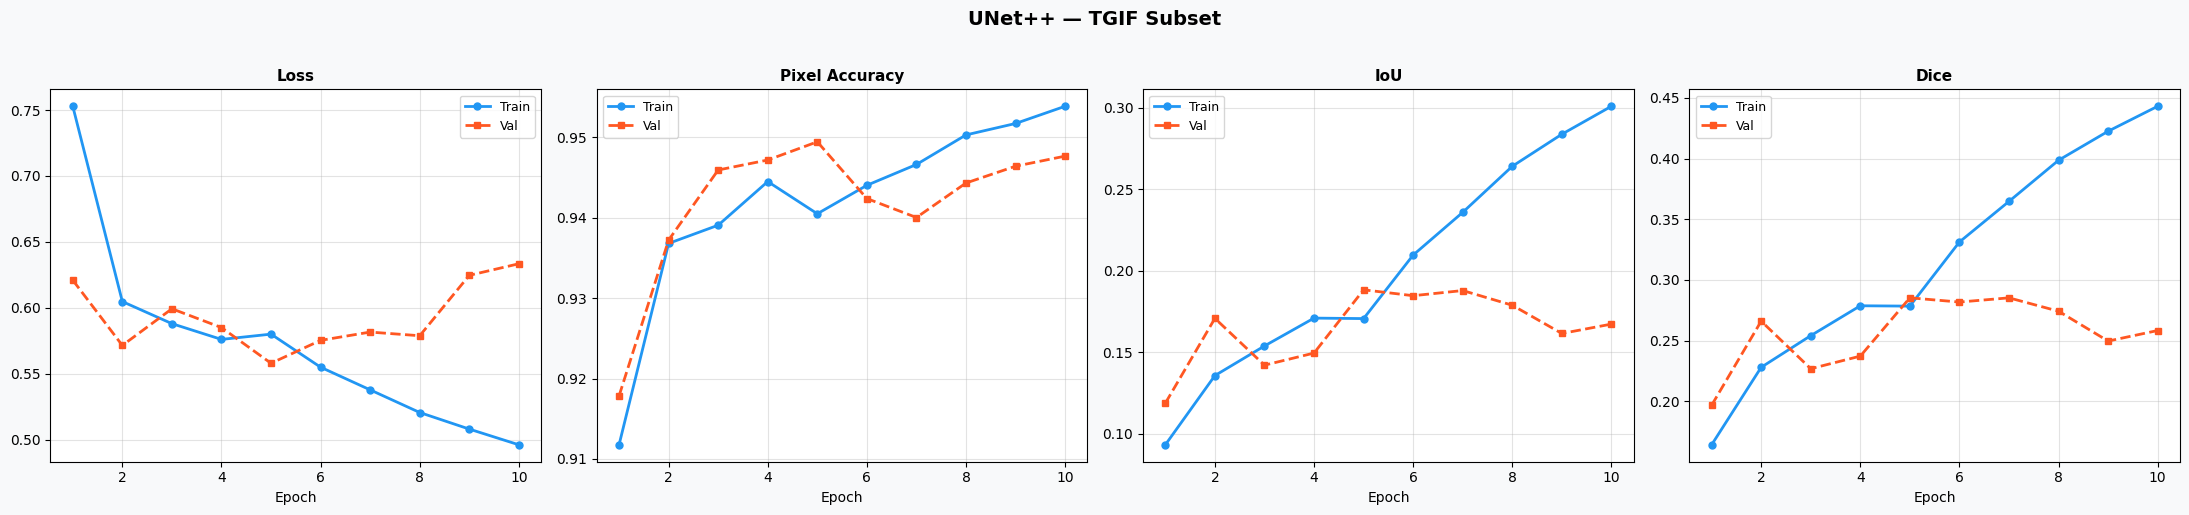

✔ Saved: /kaggle/working/training_curves_unetpp.png


In [11]:
def plot_history(h, run_name='unetpp'):
    metrics = [
        ('train_loss', 'val_loss', 'Loss'),
        ('train_acc',  'val_acc',  'Pixel Accuracy'),
        ('train_iou',  'val_iou',  'IoU'),
        ('train_dice', 'val_dice', 'Dice'),
    ]
    fig, axes = plt.subplots(1, 4, figsize=(22, 5), facecolor='#f8f9fa')
    for ax, (tr_k, vl_k, name) in zip(axes, metrics):
        ep = range(1, len(h[tr_k]) + 1)
        ax.plot(ep, h[tr_k], 'o-', label='Train',
                linewidth=2, color='#2196F3', markersize=5)
        ax.plot(ep, h[vl_k], 's--', label='Val',
                linewidth=2, color='#FF5722', markersize=5)
        ax.set_title(name, fontsize=11, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.35)
        ax.set_facecolor('#ffffff')
    plt.suptitle('UNet++ — TGIF Subset',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    p = os.path.join(OUT_DIR, f'training_curves_{run_name}.png')
    plt.savefig(p, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✔ Saved: {p}')

plot_history(history)

In [13]:
@torch.no_grad()
def full_evaluation(model, loader, run_name, history, split_name='test'):
    model.eval()
    all_pp, all_pt, all_ip, all_it = [], [], [], []

    print(f'\n🔍 Evaluating [{run_name}] on {split_name}...')
    for imgs, masks, labels in tqdm(loader, desc=f'Eval {run_name}'):
        imgs = imgs.to(DEVICE, non_blocking=True)
        with autocast('cuda'):
            logits = model(imgs)
        probs     = torch.sigmoid(logits).cpu().numpy()
        masks_np  = masks.numpy()
        labels_np = labels.numpy()
        for i in range(probs.shape[0]):
            pred = (probs[i, 0] > THRESHOLD).astype(np.int32).flatten()
            gt   = masks_np[i, 0].astype(np.int32).flatten()
            all_pp.append(pred); all_pt.append(gt)
            all_ip.append(1 if pred.max() > 0 else 0)
            all_it.append(int(labels_np[i]))

    pp    = np.concatenate(all_pp); pt = np.concatenate(all_pt)
    ip    = np.array(all_ip);       it = np.array(all_it)
    inter = ((pp==1) & (pt==1)).sum()
    union = ((pp==1) | (pt==1)).sum()

    pixel = {
        'accuracy' : float(accuracy_score(pt, pp)),
        'precision': float(precision_score(pt, pp, zero_division=0)),
        'recall'   : float(recall_score(pt, pp, zero_division=0)),
        'f1'       : float(f1_score(pt, pp, zero_division=0)),
        'iou'      : float(inter / (union + 1e-8)),
        'dice'     : float(2*inter / (pp.sum()+pt.sum()+1e-8)),
    }
    image = {
        'accuracy' : float(accuracy_score(it, ip)),
        'precision': float(precision_score(it, ip, zero_division=0)),
        'recall'   : float(recall_score(it, ip, zero_division=0)),
        'f1'       : float(f1_score(it, ip, zero_division=0)),
    }
    total_p = sum(p.numel() for p in model.parameters())

    print(f"\n{'='*50}")
    print(f"  [{run_name}] on {split_name}")
    print(f"  Pixel Acc    : {pixel['accuracy']:.4f}")
    print(f"  Pixel Prec   : {pixel['precision']:.4f}")
    print(f"  Pixel Recall : {pixel['recall']:.4f}")
    print(f"  Pixel F1     : {pixel['f1']:.4f}")
    print(f"  IoU          : {pixel['iou']:.4f}")
    print(f"  Dice         : {pixel['dice']:.4f}")
    print(f"  Image F1     : {image['f1']:.4f}")
    print(f"  Total Params : {total_p/1e6:.2f} M")
    print(f"  Total Time   : {history['total_time']:.0f}s")

    return {
        'pixel'   : pixel,
        'image'   : image,
        'pixel_cm': confusion_matrix(pt, pp),
        'image_cm': confusion_matrix(it, ip)
                    if len(set(it)) > 1
                    else np.array([[0,0],[0,0]]),
    }


# ── Load best checkpoint if it exists, else use the trained model ──
save_path = os.path.join(OUT_DIR, 'best_unetpp.pth')

model_eval = build_model()

if os.path.exists(save_path):
    model_eval.load_state_dict(
        torch.load(save_path, map_location=DEVICE))
    print(f'✓ Loaded best checkpoint from {save_path}')
else:
    # Checkpoint not found — copy weights from the trained model in memory
    print(f'⚠ No checkpoint found at {save_path}')
    print(f'  Using trained model weights directly from memory.')
    model_eval.load_state_dict(model.state_dict())
    # Also save it now so downstream cells have the file
    torch.save(model.state_dict(), save_path)
    print(f'✓ Saved current model to {save_path}')

results = full_evaluation(model_eval, test_loader, 'unetpp', history)

⚠ No checkpoint found at /kaggle/working/best_unetpp.pth
  Using trained model weights directly from memory.
✓ Saved current model to /kaggle/working/best_unetpp.pth

🔍 Evaluating [unetpp] on test...


Eval unetpp: 100%|██████████| 129/129 [00:19<00:00,  6.51it/s]



  [unetpp] on test
  Pixel Acc    : 0.9537
  Pixel Prec   : 0.4298
  Pixel Recall : 0.2970
  Pixel F1     : 0.3513
  IoU          : 0.2131
  Dice         : 0.3513
  Image F1     : 0.7622
  Total Params : 39.76 M
  Total Time   : 1947s


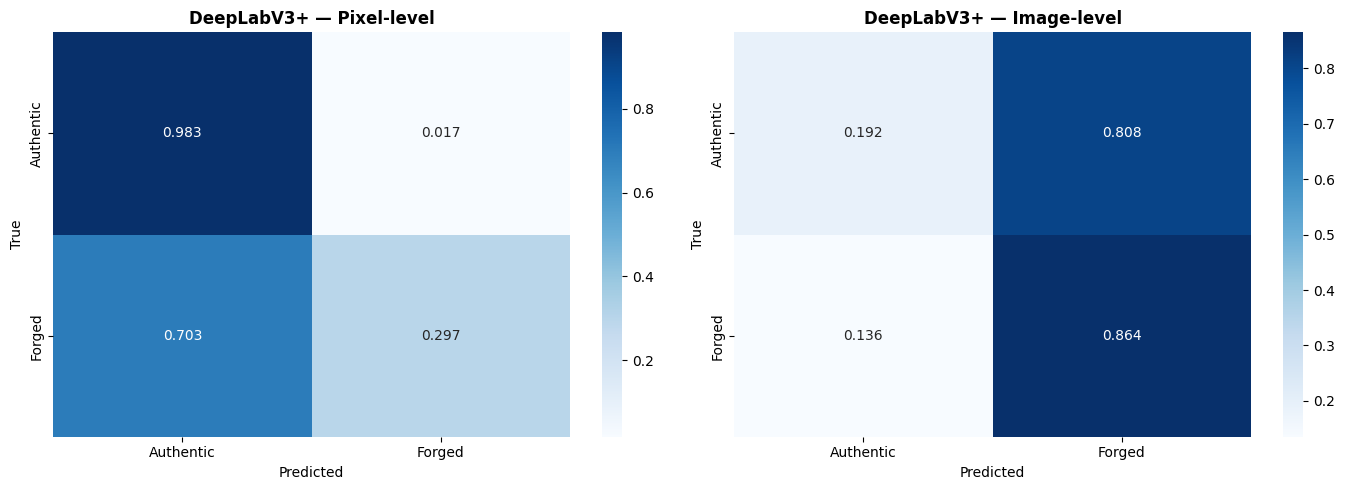

✔ Saved: /kaggle/working/confusion_matrices_deeplabv3p.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (cm_key, title) in zip(axes, [
        ('pixel_cm', 'Pixel-level'),
        ('image_cm', 'Image-level')]):
    cm      = results[cm_key].astype(float)
    cm_norm = cm / (cm.sum(axis=1, keepdims=True) + 1e-8)
    sns.heatmap(cm_norm, annot=True, fmt='.3f', cmap='Blues',
                xticklabels=['Authentic', 'Forged'],
                yticklabels=['Authentic', 'Forged'], ax=ax)
    ax.set_title(f'DeepLabV3+ — {title}', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
plt.tight_layout()
p = os.path.join(OUT_DIR, 'confusion_matrices_deeplabv3p.png')
plt.savefig(p, dpi=150, bbox_inches='tight')
plt.show()
print(f'✔ Saved: {p}')

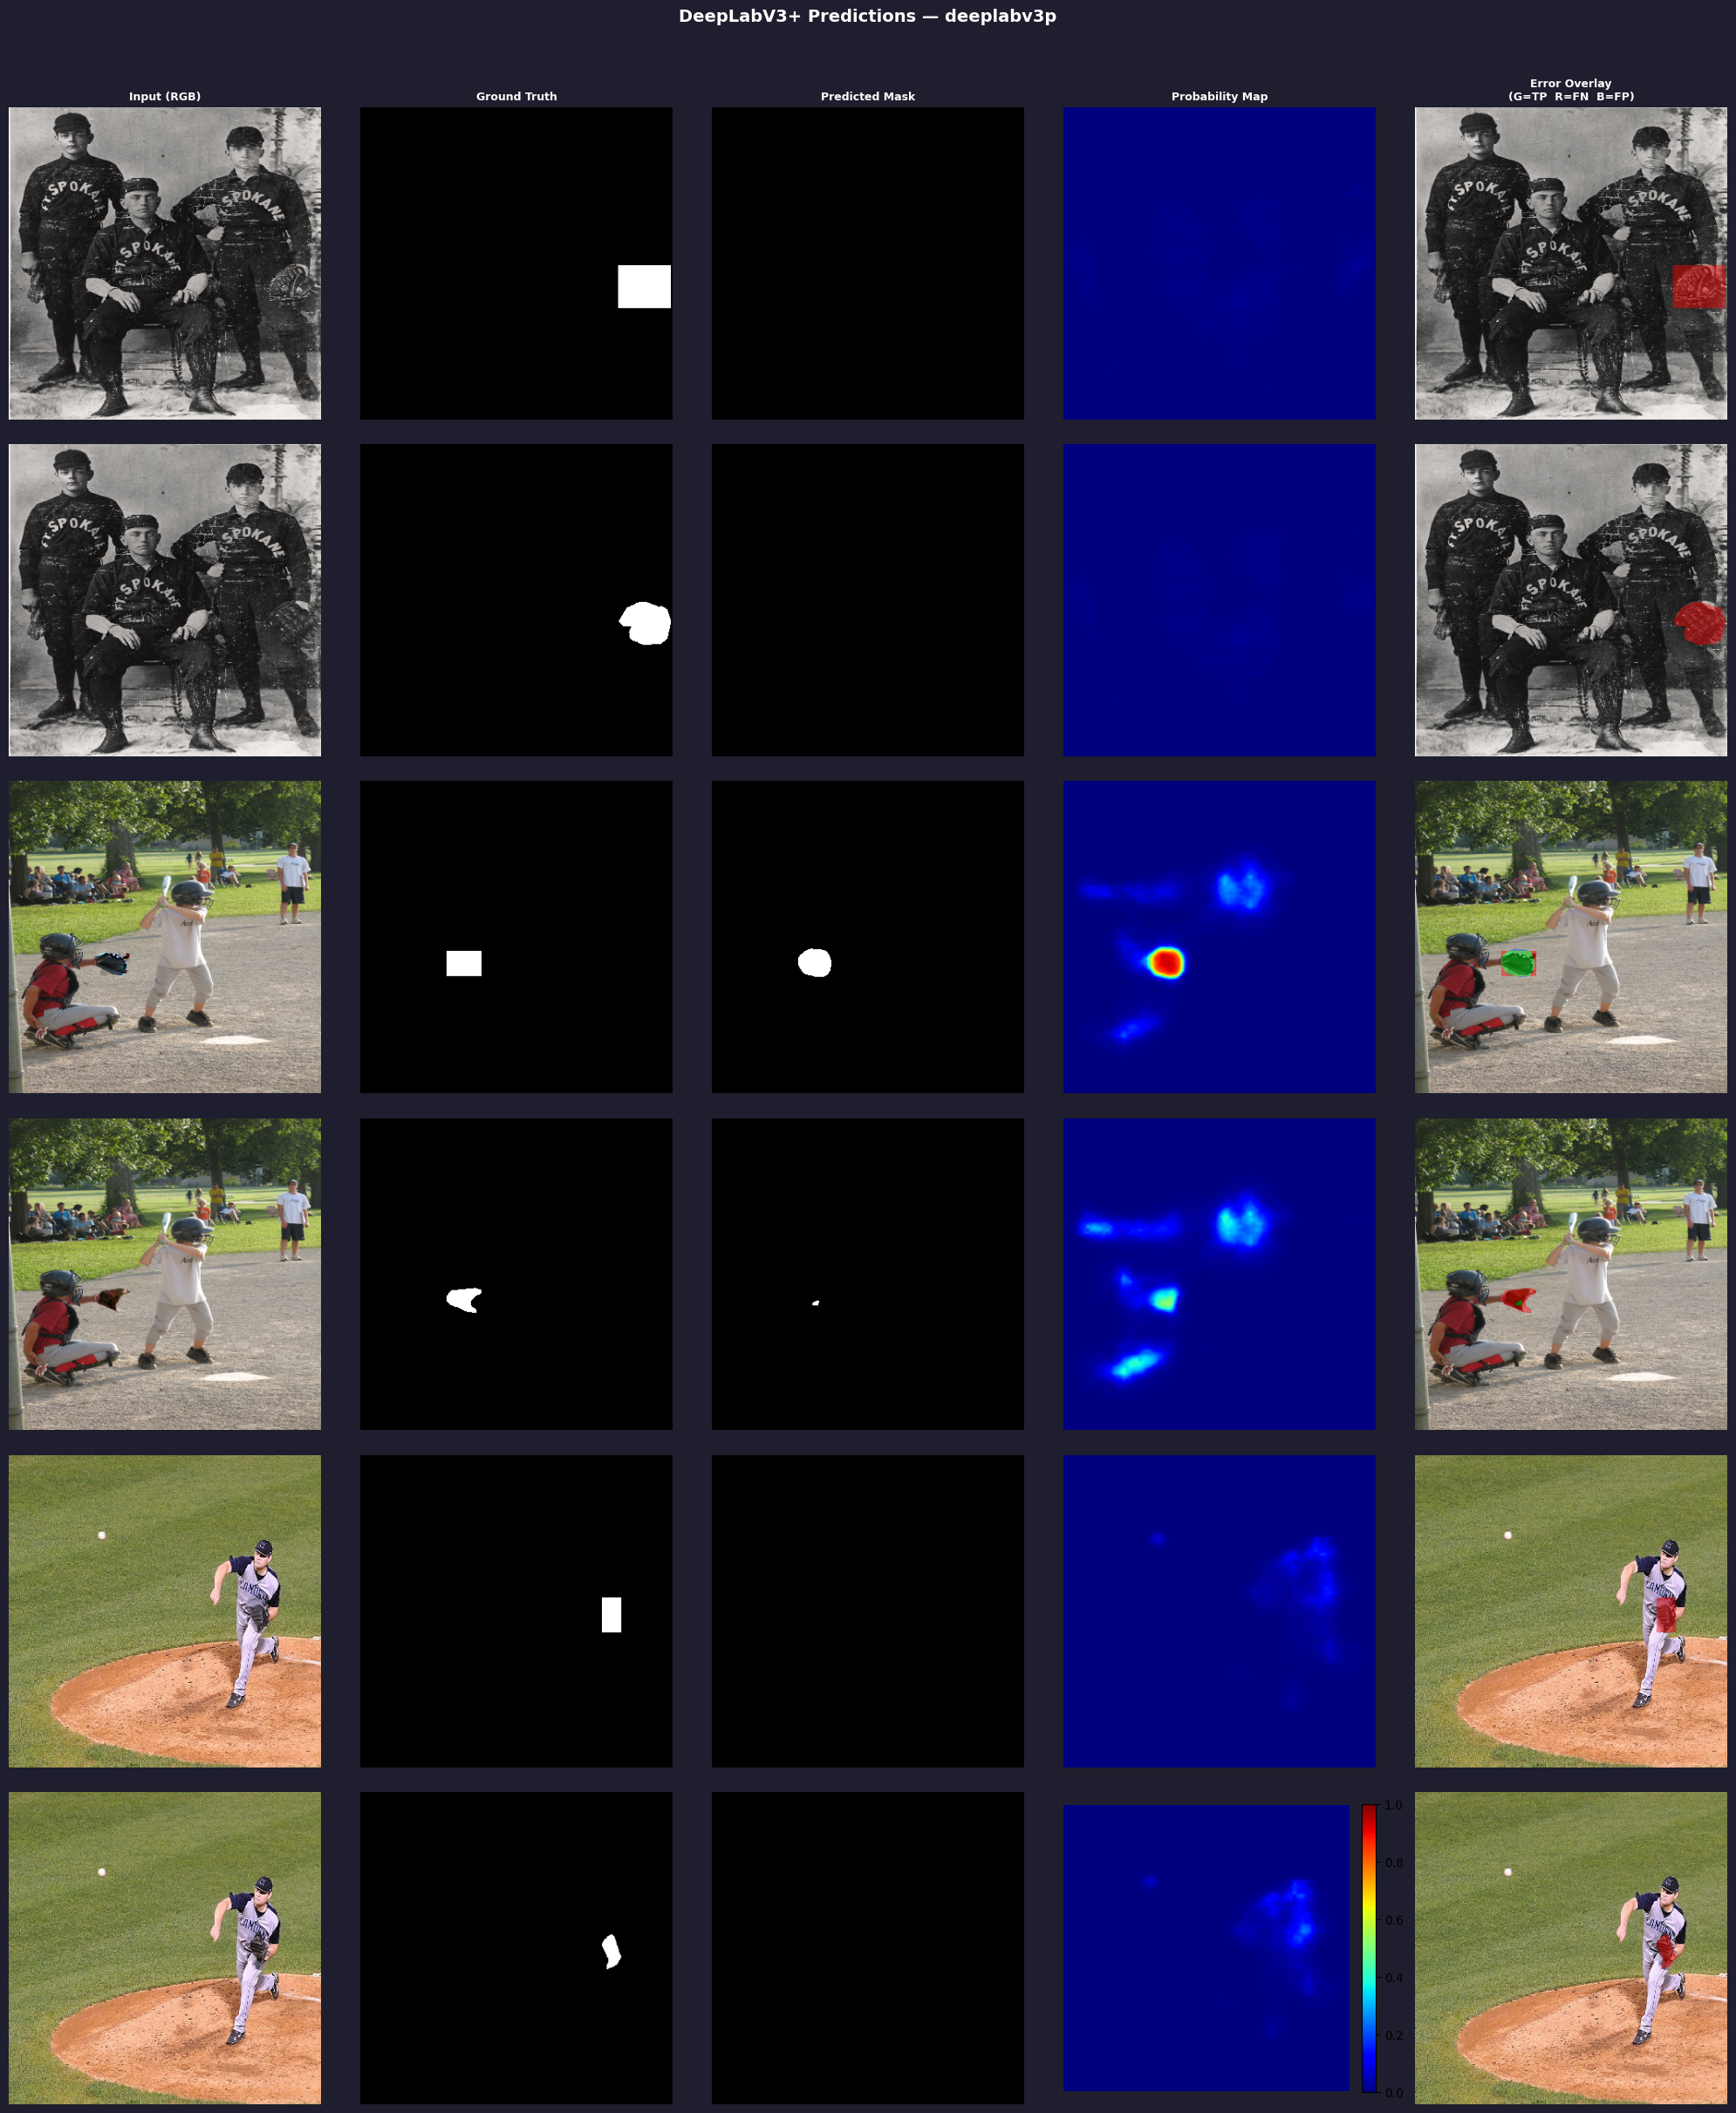

✔ Saved: /kaggle/working/predictions_deeplabv3p.png


In [18]:
def denorm(tensor):
    img = tensor.permute(1, 2, 0).cpu().numpy()
    return np.clip(img * np.array(STD) + np.array(MEAN), 0, 1)

def make_error_overlay(img_np, gt, pred, alpha=0.45):
    overlay = img_np.copy()
    for mask, colour in [
            ((gt==1)&(pred==1), np.array([0.0, 0.9, 0.0])),
            ((gt==1)&(pred==0), np.array([1.0, 0.0, 0.0])),
            ((gt==0)&(pred==1), np.array([0.0, 0.4, 1.0]))]:
        overlay[mask] = (1-alpha)*overlay[mask] + alpha*colour
    return (overlay * 255).astype(np.uint8)

@torch.no_grad()
def show_predictions(model, loader, run_name='deeplabv3p', n_samples=6):
    model.eval()
    imgs, masks, _ = next(iter(loader))
    n = min(n_samples, imgs.size(0))

    with autocast('cuda'):
        logits = model(imgs.to(DEVICE))
    probs = torch.sigmoid(logits).cpu()
    preds = (probs > THRESHOLD).float()

    col_titles = [
        'Input (RGB)', 'Ground Truth',
        'Predicted Mask', 'Probability Map',
        'Error Overlay\n(G=TP  R=FN  B=FP)']

    fig, axes = plt.subplots(n, 5, figsize=(20, 4*n),
                             facecolor='#1e1e2e')
    if n == 1:
        axes = axes[np.newaxis, :]

    for i in range(n):
        img_np = denorm(imgs[i])
        gt_np  = masks[i, 0].numpy()
        pr_np  = preds[i, 0].numpy()
        pb_np  = probs[i, 0].numpy()

        tp   = float(((pr_np==1)&(gt_np==1)).sum())
        fp   = float(((pr_np==1)&(gt_np==0)).sum())
        fn   = float(((pr_np==0)&(gt_np==1)).sum())
        iou  = tp / (tp + fp + fn + 1e-8)
        dice = 2*tp / (2*tp + fp + fn + 1e-8)

        axes[i,0].imshow(img_np)
        axes[i,0].set_ylabel(
            f'#{i+1}  IoU:{iou:.3f}  Dice:{dice:.3f}',
            fontsize=8, color='white', rotation=0,
            labelpad=90, va='center')
        axes[i,1].imshow(gt_np,  cmap='gray', vmin=0, vmax=1)
        axes[i,2].imshow(pr_np,  cmap='gray', vmin=0, vmax=1)
        im = axes[i,3].imshow(pb_np, cmap='jet', vmin=0, vmax=1)
        if i == n-1:
            plt.colorbar(im, ax=axes[i,3], fraction=0.046, pad=0.04)
        axes[i,4].imshow(make_error_overlay(img_np, gt_np, pr_np))

        for j in range(5):
            axes[i,j].axis('off')
            if i == 0:
                axes[i,j].set_title(
                    col_titles[j], fontsize=9,
                    color='white', fontweight='bold', pad=6)

    plt.suptitle(f'DeepLabV3+ Predictions — {run_name}',
                 fontsize=14, color='white',
                 fontweight='bold', y=1.01)
    plt.tight_layout()
    p = os.path.join(OUT_DIR, f'predictions_{run_name}.png')
    plt.savefig(p, dpi=150, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.show()
    print(f'✔ Saved: {p}')

show_predictions(model_eval, val_loader, n_samples=6)

In [19]:
to_save = {
    'model'        : 'DeepLabV3+ (ResNet-50)',
    'pixel_metrics': results['pixel'],
    'image_metrics': results['image'],
    'pixel_cm'     : results['pixel_cm'].tolist(),
    'image_cm'     : results['image_cm'].tolist(),
    'history'      : {k: v for k, v in history.items()
                      if isinstance(v, list)},
    'total_time'   : history['total_time'],
    'config': {
        'IMG_SIZE'  : IMG_SIZE,
        'BATCH_SIZE': BATCH_SIZE,
        'EPOCHS'    : EPOCHS,
        'LR'        : LR,
        'PATIENCE'  : PATIENCE,
        'THRESHOLD' : THRESHOLD,
    }
}
json_path = os.path.join(OUT_DIR, 'deeplabv3p_all_results.json')
with open(json_path, 'w') as f:
    json.dump(to_save, f, indent=2, default=str)
print(f'✓ Saved {json_path}')
print('⚠  Download files from the Output tab before your session ends!')

✓ Saved /kaggle/working/deeplabv3p_all_results.json
⚠  Download files from the Output tab before your session ends!
